In [1]:
%load_ext autoreload
%autoreload 2

In [10]:
import os

import joblib
import numpy as np
import pandas as pd
import psp_helper
from hydra import (compose, initialize, initialize_config_dir,
                   initialize_config_module)
from omegaconf import OmegaConf
from psp_helper.config import MainConfig
from psp_helper.create_windows import load_windows_and_labels
from sklearn.ensemble import (AdaBoostClassifier, AdaBoostRegressor,
                              HistGradientBoostingClassifier,
                              HistGradientBoostingRegressor,
                              RandomForestClassifier, RandomForestRegressor)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor

from fcl_psp.models.run_model import create_fault_classes

In [47]:
dataset_directory = r"C:\Users\user\Datasets\windows_tmp"
X_filename = "X_new_double_line_90kv_multi_fault_10k_0.05_0.005_9150.npz"
y_filename = "y_new_double_line_90kv_multi_fault_10k_0.05_0.005_9150.npz"
X_path = os.path.join(dataset_directory, X_filename)
y_path = os.path.join(dataset_directory, y_filename)

In [48]:
windows = np.load(X_path, allow_pickle=True)["X"]
labels = np.load(y_path, allow_pickle=True)["y"]

In [49]:
labels = pd.DataFrame(
    labels,
    columns=[
        "fault",
        "fault_target",
        "sc_location",
        "sc_type",
        "phase_select",
        "sample_id",
        "start_time",
    ],
)
# Set appropriate data types for the DataFrame columns
labels = labels.astype({"fault_target": "str", "sc_location": "float"})
labels.reset_index(drop=True, inplace=True)

In [50]:
labels.head()

,fault,fault_target,sc_location,sc_type,phase_select,sample_id,start_time
0,0,Line_2_3_a,19.547918,2,1,0,0.34875
1,0,Line_2_3_a,19.547918,2,1,0,0.35375
2,0,Line_2_3_a,19.547918,2,1,0,0.35875
3,0,Line_2_3_a,19.547918,2,1,0,0.36375
4,0,Line_2_3_a,19.547918,2,1,0,0.36875


In [51]:
print(f"Windows shape: {windows.shape}")
print(f"Labels shape: {labels.shape}")

Windows shape: (207506, 320, 48)
Labels shape: (207506, 7)


In [52]:
X = windows.reshape(windows.shape[0], -1)
print(f"X shape: {X.shape}")
del windows

X shape: (207506, 15360)


In [53]:
fault_target = "fault_class"

In [54]:
if fault_target == "fault_class":
        labels["fault_class"] = create_fault_classes(labels)

In [55]:
labels.head()

,fault,fault_target,sc_location,sc_type,phase_select,sample_id,start_time,fault_class
0,0,Line_2_3_a,19.547918,2,1,0,0.34875,0
1,0,Line_2_3_a,19.547918,2,1,0,0.35375,0
2,0,Line_2_3_a,19.547918,2,1,0,0.35875,0
3,0,Line_2_3_a,19.547918,2,1,0,0.36375,0
4,0,Line_2_3_a,19.547918,2,1,0,0.36875,0


In [69]:
if fault_target == "fault_location":
    y = labels["sc_location"].astype("float")
    print("Converted fault_location values to percentage (0-1 scale).")
    # log min, max, and mean of fault_location
    print(
        f"Fault location - min: {y.min():.4f}, max: {y.max():.4f}, mean: {y.mean():.4f}"
    )
    # Keep only X and y only where "fault" is 1
    mask = labels["fault"] == 1
    X = X[mask]
    y = y[mask]
    labels = labels[mask]
    print(f"Filtered X shape: {X.shape}, y shape: {y.shape}")

elif fault_target == "fault_line":
    y = labels["fault_target"].astype("str")

elif fault_target == "fault_class":
    y = labels["fault_class"]
    y = y.astype(int)
    print(f"Fault classes: {y.unique()}")

Fault classes: [ 0  6  9 10  3  1  5  7  8  2  4]


In [70]:
# Get all unique sample_ids
unique_ids = labels["sample_id"].unique()

# Split the sample_ids
train_ids, test_ids = train_test_split(unique_ids, test_size=0.2, random_state=42)

# Create boolean masks
train_mask = labels["sample_id"].isin(train_ids)
test_mask = labels["sample_id"].isin(test_ids)

In [71]:
# Apply masks to X and y
X_train, X_test = X[train_mask], X[test_mask]
del X
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

NameError: name 'X' is not defined

In [72]:
y_train, y_test = y[train_mask], y[test_mask]


print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

y_train shape: (165991,)
y_test shape: (41515,)


In [73]:
y_train.head()

23    0
24    0
25    0
26    0
27    0
Name: fault_class, dtype: int32

In [61]:
# Scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [62]:
models_path = r"C:\Users\user\Repositories\fault-classification-localization\models"

In [63]:
import os
import re
from datetime import datetime


def get_newest_model(
    topology: str, model_name: str, window_length: str, folder: str = "."
) -> str:
    pattern = re.compile(
        rf"{re.escape(model_name)}_{re.escape(topology)}_{re.escape(window_length)}_([0-9\-]+_[0-9\-]+)\.joblib$"
    )
    newest_model = None
    newest_time = None

    for filename in os.listdir(folder):
        match = pattern.match(filename)
        if match:
            timestamp_str = match.group(1)
            try:
                timestamp = datetime.strptime(timestamp_str, "%Y-%m-%d_%H-%M-%S")
                if newest_time is None or timestamp > newest_time:
                    newest_time = timestamp
                    newest_model = os.path.join(folder, filename)
            except ValueError:
                continue  # skip malformed timestamps

    return newest_model

In [64]:
# hist_gradient_boosting_classifier_new_double_line_90kv_multi_fault_10k_0.01_2025-07-19_07-45-42.joblib
# naming_convention = (f"{model_name}_{window_length}_{timestamp}.joblib"

model = get_newest_model(
    model_name="mlp_classifier",
    topology="new_double_line_90kv_multi_fault_10k",
    window_length="0.05",
    folder=models_path,
)
print("Newest model:", model)

# Load the model
mlp_classifier = joblib.load(model)
mlp_classifier

Newest model: C:\Users\user\Repositories\fault-classification-localization\models\mlp_classifier_new_double_line_90kv_multi_fault_10k_0.05_2025-07-19_06-43-54.joblib


MLPClassifier(random_state=42)

In [74]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

# Define all your models
models = {
    "MLP Classifier": mlp_classifier,
}

# Evaluate each model
for model_name, model in models.items():
    print(f"\nEvaluating model: {model_name}")

    # Predict
    y_pred = model.predict(X_test)

    # Metrics for classification
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Evaluating model: MLP Classifier
Accuracy: 0.9984
F1 Score: 0.9984
Precision: 0.9984
Recall: 0.9984

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25270
           1       1.00      1.00      1.00      4041
           2       1.00      1.00      1.00      1134
           3       1.00      1.00      1.00      1368
           4       0.99      1.00      0.99      1206
           5       0.99      0.99      0.99      1494
           6       1.00      1.00      1.00      1422
           7       1.00      1.00      1.00      1386
           8       0.99      0.99      0.99      1422
           9       1.00      1.00      1.00      1305
          10       1.00      0.98      0.99      1467

    accuracy                           1.00     41515
   macro avg       1.00      1.00      1.00     41515
weighted avg       1.00      1.00      1.00     41515



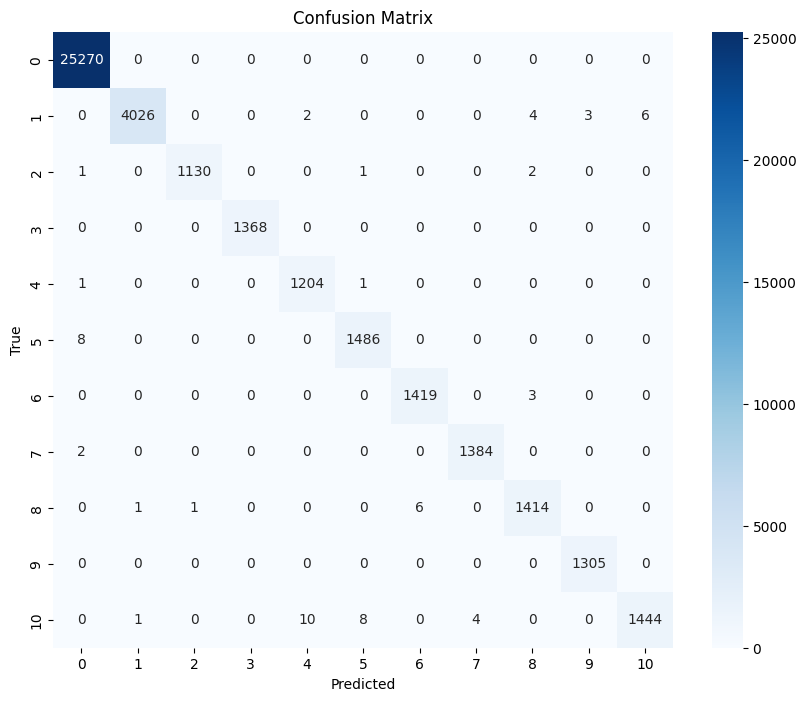

In [75]:
# Plot confusin matrix with seaborn
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=np.unique(y),
    yticklabels=np.unique(y),
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

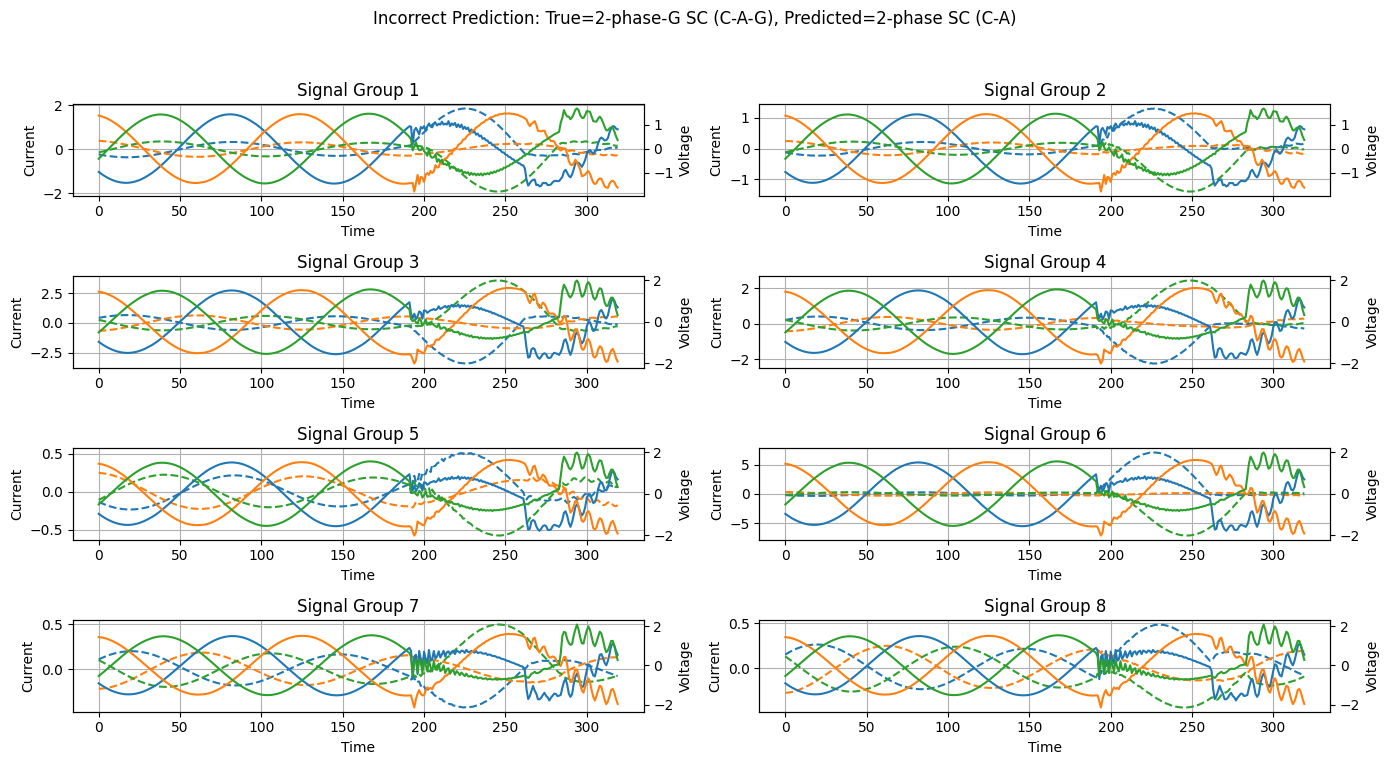

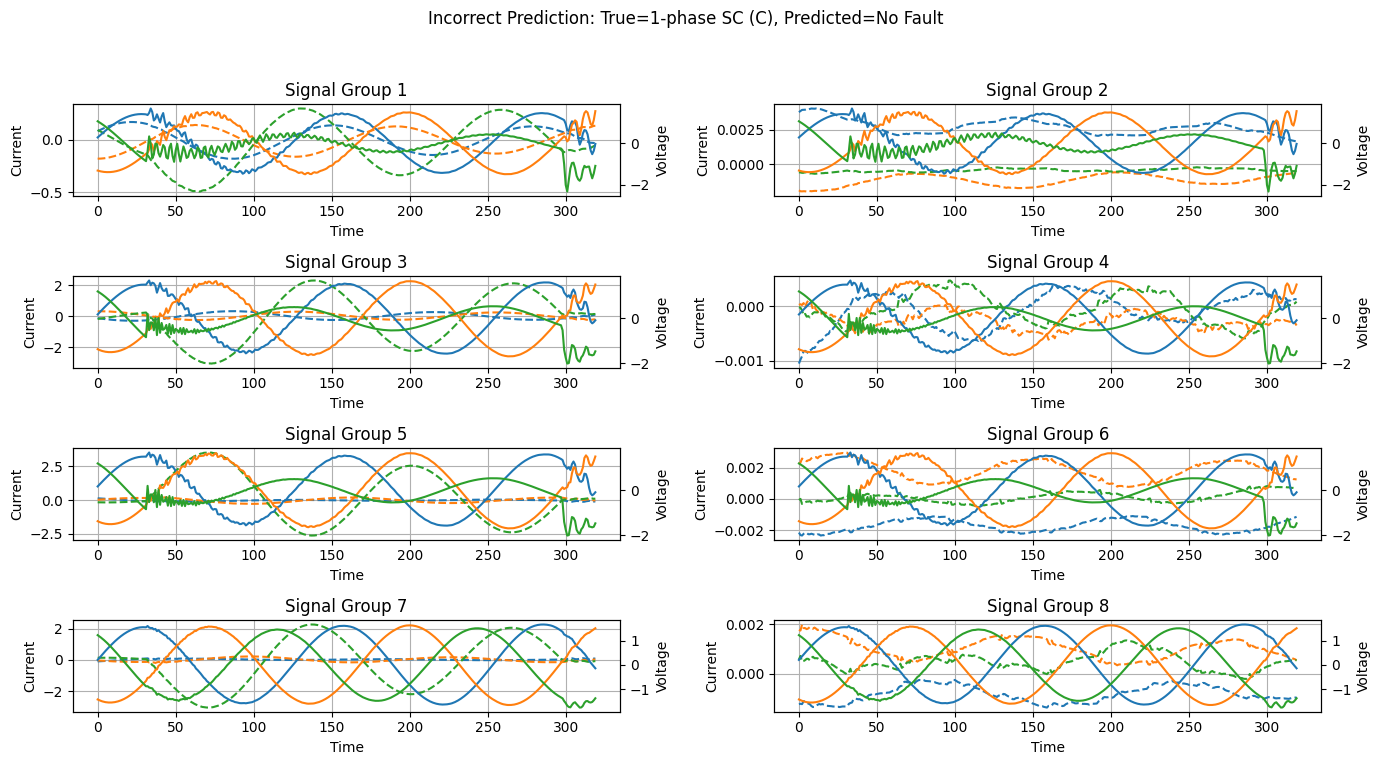

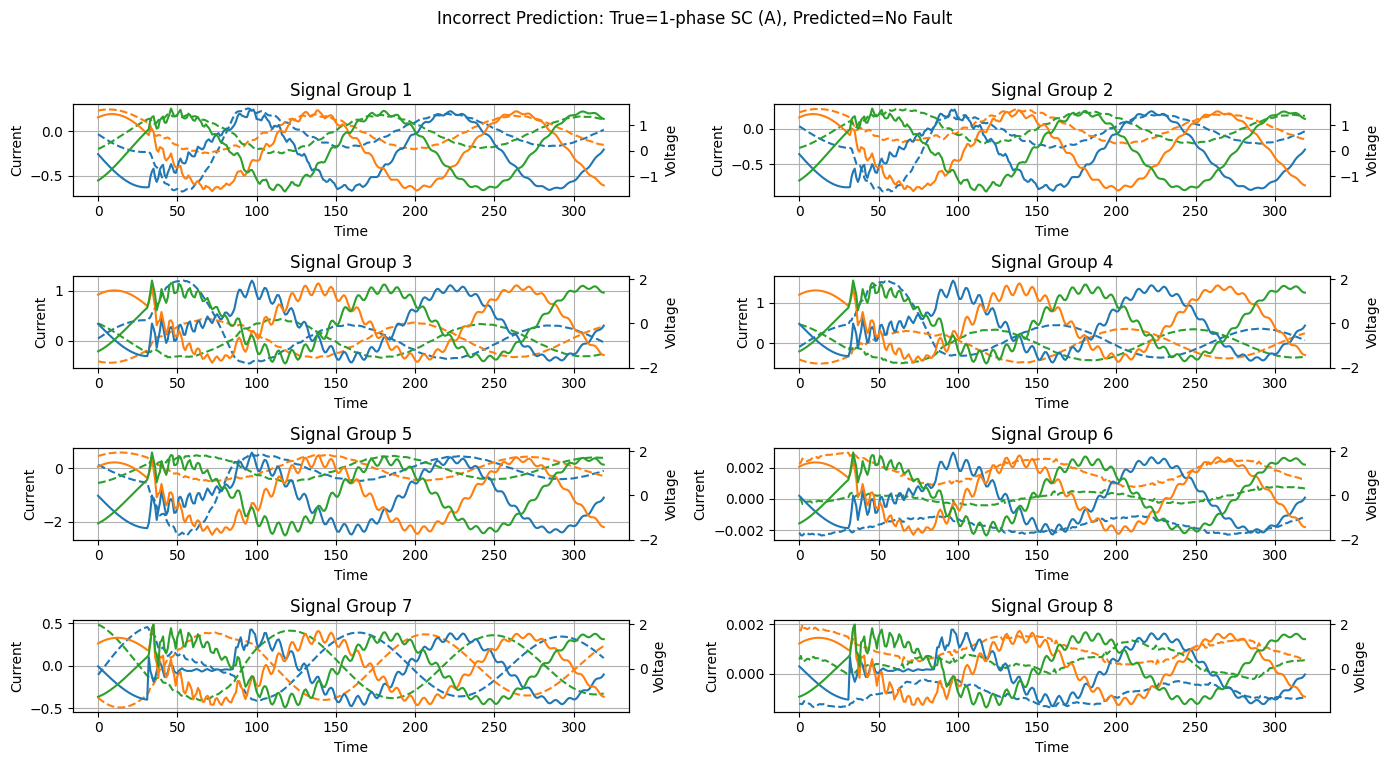

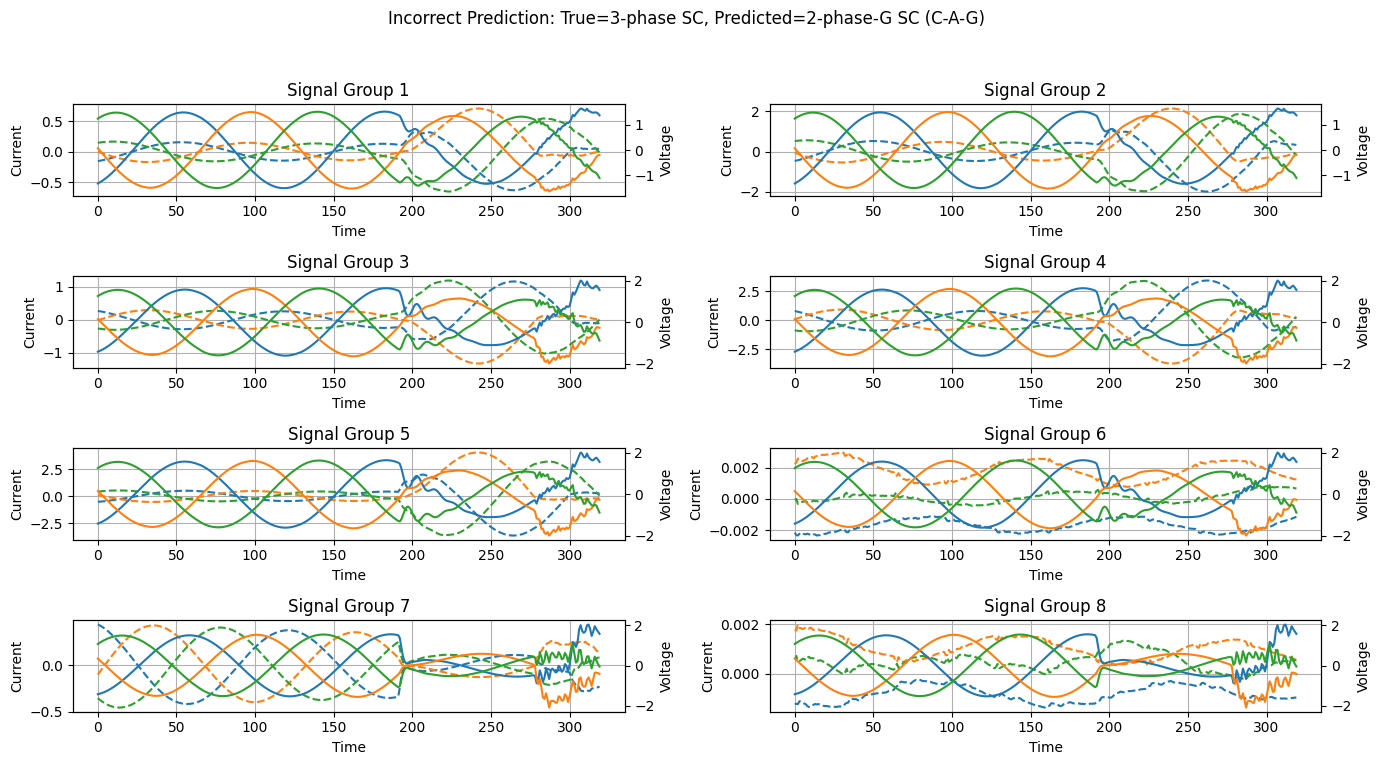

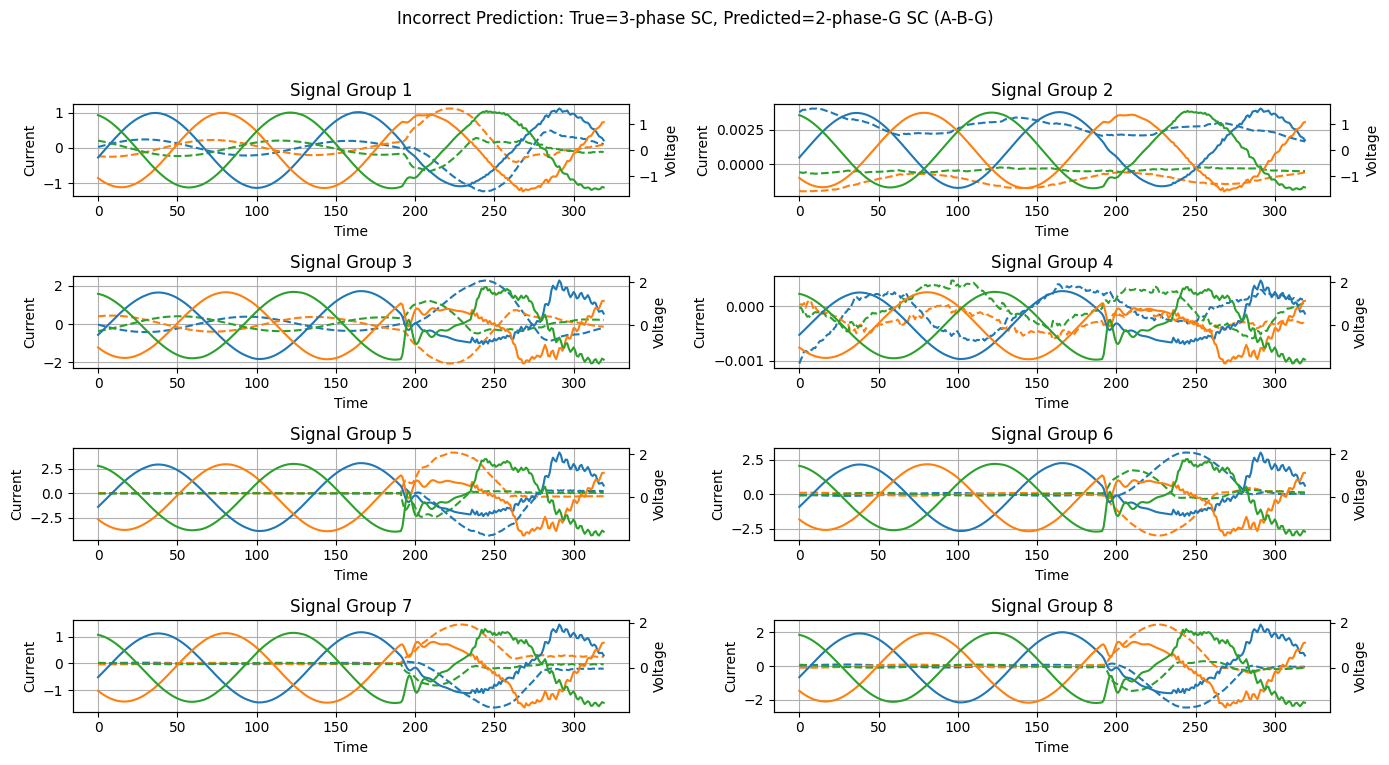

In [89]:
from psp_helper.constants import FAULT_ID_TO_LABEL

# Plot incorrect predictions
incorrect_indices = np.where(y_pred != y_test)[0]

# Plot the incorrect predictions
for idx in incorrect_indices[:5]:  # Limit to first 3 incorrect predictions
    plt.figure(figsize=(14, 8))

    sample_signal = X_test[idx].reshape(320, 48)  # shape: (time, 48)

    for i in range(8):  # 8 groups of 6 signals each
        ax = plt.subplot(4, 2, i + 1)
        # Current signals: columns 0–2 of this block
        for j in range(3):
            ax.plot(sample_signal[:, i * 6 + j], label=f"I{j+1}", linestyle="--")
        ax.set_ylabel("Current")
        ax.grid(True)

        # Voltage signals: columns 3–5 of this block (on secondary y-axis)
        ax2 = ax.twinx()
        for j in range(3, 6):
            ax2.plot(sample_signal[:, i * 6 + j], label=f"V{j-2}", linestyle="-")
        ax2.set_ylabel("Voltage")

        ax.set_title(f"Signal Group {i + 1}")
        ax.set_xlabel("Time")

    plt.suptitle(
        f"Incorrect Prediction: True={FAULT_ID_TO_LABEL[y_test.iloc[idx]]}, "
        f"Predicted={FAULT_ID_TO_LABEL[y_pred[idx]]}"
    )
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

---

[OVERALL] Mean: 22.15 min, Std: 43.08 min
[OVERALL] Min: 0.05 min, Max: 272.40 min

[PER FAULT TARGET]
                 mean    std
fault_target                
fault_class     16.99  44.43
fault_location  25.52  42.23


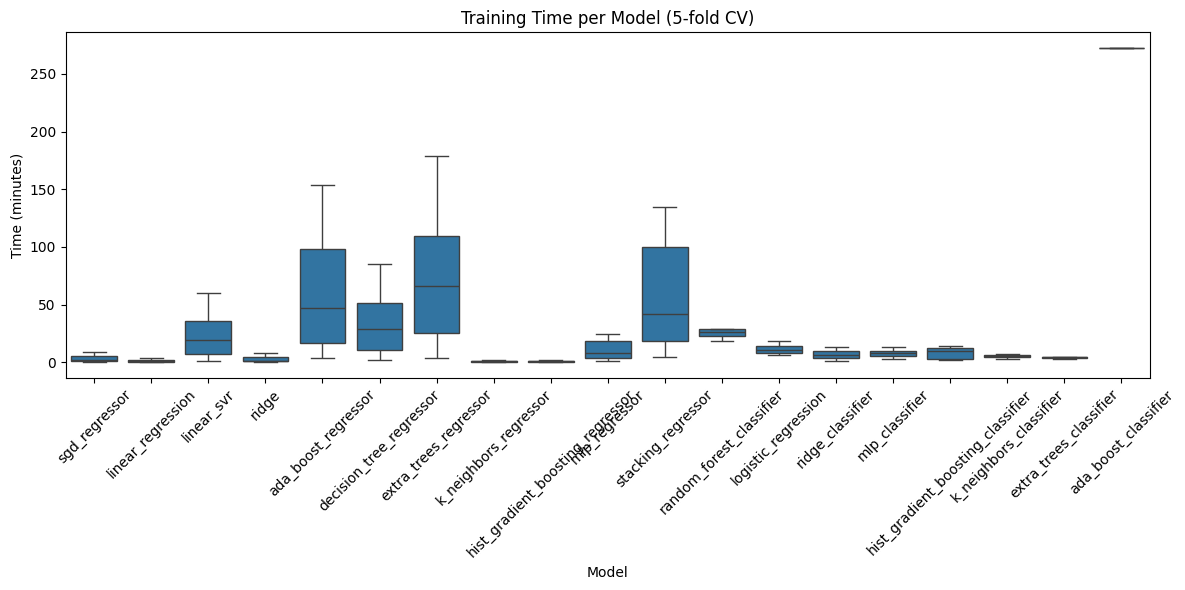

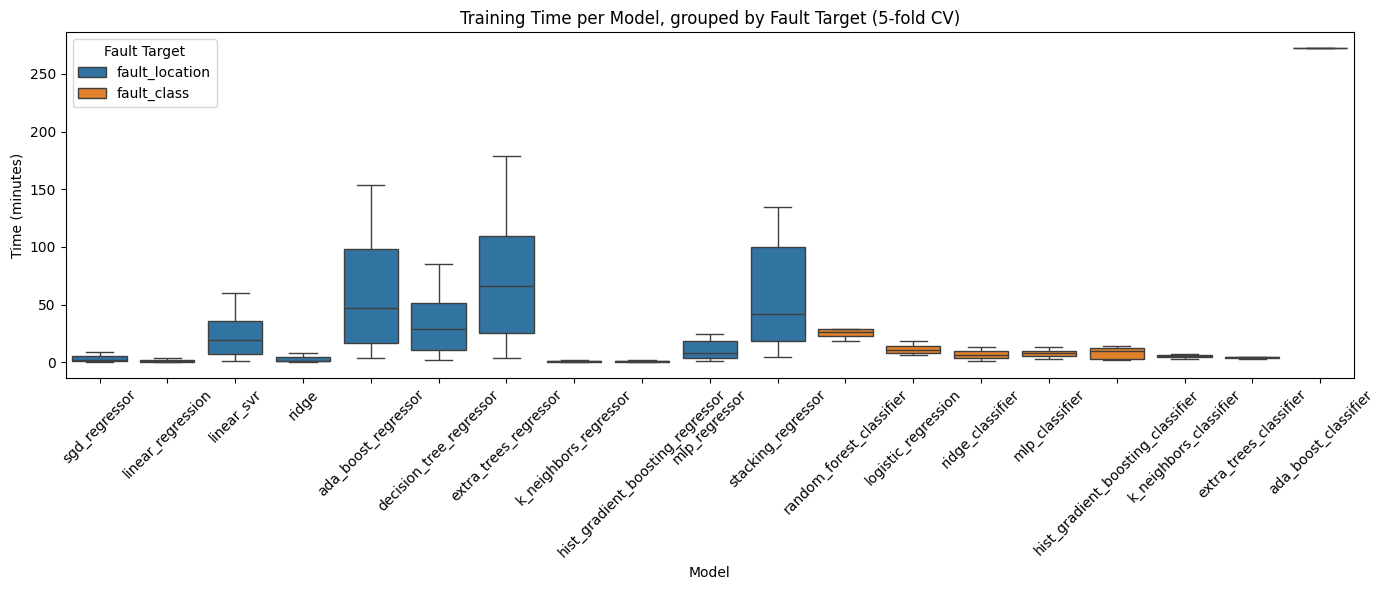

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV
df = pd.read_csv(r"C:\Users\user\Downloads\runs.csv")


# Convert duration strings to minutes
def convert_to_minutes(duration_str):
    duration_str = str(duration_str).strip().lower()
    if "h" in duration_str:
        return float(duration_str.replace("h", "")) * 60
    elif "min" in duration_str:
        return float(duration_str.replace("min", ""))
    elif "s" in duration_str:
        return float(duration_str.replace("s", "")) / 60
    else:
        return np.nan


df["Duration_min"] = df["Duration"].apply(convert_to_minutes)
df["Time_per_model"] = df["Duration_min"] / 5  # 5-fold CV

# Fill missing model names if needed
if "model" not in df.columns:
    df["model"] = [f"Model {i+1}" for i in range(len(df))]

# --- 1. Overall mean & std
mean_all = df["Time_per_model"].mean()
std_all = df["Time_per_model"].std()
print(f"[OVERALL] Mean: {mean_all:.2f} min, Std: {std_all:.2f} min")

# Also print min and max
min_all = df["Time_per_model"].min()
max_all = df["Time_per_model"].max()

print(f"[OVERALL] Min: {min_all:.2f} min, Max: {max_all:.2f} min")

# --- 2. Per fault target
if "fault_target" in df.columns:
    print("\n[PER FAULT TARGET]")
    fault_grouped = df.groupby("fault_target")["Time_per_model"]
    stats_per_target = fault_grouped.agg(["mean", "std"]).round(2)
    print(stats_per_target)

# --- 3. Plot overall
plt.figure(figsize=(12, 6))
sns.boxplot(x="model", y="Time_per_model", data=df)
plt.xticks(rotation=45)
plt.title("Training Time per Model (5-fold CV)")
plt.xlabel("Model")
plt.ylabel("Time (minutes)")
plt.tight_layout()
plt.show()

# --- 4. Plot per fault_target
if "fault_target" in df.columns:
    plt.figure(figsize=(14, 6))
    sns.boxplot(x="model", y="Time_per_model", hue="fault_target", data=df)
    plt.xticks(rotation=45)
    plt.title("Training Time per Model, grouped by Fault Target (5-fold CV)")
    plt.xlabel("Model")
    plt.ylabel("Time (minutes)")
    plt.legend(title="Fault Target")
    plt.tight_layout()
    plt.show()